# MOABB Liu2024 pipeline verification

This notebook calls every pipeline module in order. Subject 1 is used by default for a quick, reproducible check.

In [1]:
import sys
from pathlib import Path

def find_repository_root(start=Path.cwd()):
    for directory in (start.resolve(), *start.resolve().parents):
        if (directory / 'src' / 'datautils' / 'MoabbLiu2024').is_dir():
            return directory
    raise FileNotFoundError('Could not locate the EEG repository root')

REPOSITORY_ROOT = find_repository_root()
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))
print('Repository:', REPOSITORY_ROOT)

Repository: /workspaces/EEG


## 1. Configuration — `config.py`

In [2]:
from dataclasses import asdict
from src.datautils.MoabbLiu2024.config import Liu2024Config

config = Liu2024Config(subject_ids=(1,))
asdict(config)

{'data_root': PosixPath('/workspaces/EEG/data/moabb'),
 'subject_ids': (1,),
 'l_freq': 8.0,
 'h_freq': 32.0,
 'target_sfreq': 500.0,
 'trial_start_offset_seconds': 0.0,
 'trial_stop_offset_seconds': 0.0,
 'standardize': True,
 'standardize_factor_new': 0.001,
 'standardize_init_block_seconds': 4.0,
 'preload_windows': True,
 'n_jobs': 1,
 'event_mapping': {'left_hand': 0, 'right_hand': 1}}

## 2. Load local data — `loader.py`

In [3]:
from src.datautils.MoabbLiu2024.loader import load_liu2024

dataset = load_liu2024(config.subject_ids, config.data_root)
print('Recordings:', len(dataset.datasets))
display(dataset.description)
dataset.datasets[0].raw

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Recordings: 1


/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


,subject,session,run
0,1,0,0


<RawEDF | sub-01_task-motor-imagery_eeg.edf, 32 x 160000 (320.0 s), ~39.1 MiB, data loaded>

## 3. Validate raw recordings — `validation.py`

In [4]:
import pandas as pd
from src.datautils.MoabbLiu2024.validation import validate_liu2024

raw_summary = validate_liu2024(dataset)
display(pd.DataFrame(raw_summary))

,recording,subject,session,run,sfreq,n_eeg_channels,left_hand_trials,right_hand_trials
0,0,1,0,0,500.0,29,20,20


## 4. Keep EEG channels — `channels.py`

In [5]:
from src.datautils.MoabbLiu2024.channels import select_eeg_channels

select_eeg_channels(dataset, n_jobs=config.n_jobs)
eeg_summary = validate_liu2024(dataset, require_eeg_only=True)
raw = dataset.datasets[0].raw
print('Types:', sorted(set(raw.get_channel_types())))
print('Channels:', len(raw.ch_names), raw.ch_names)
display(pd.DataFrame(eeg_summary))

Types: ['eeg']
Channels: 29 ['FP1', 'FP2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'FCz', 'FC3', 'FC4', 'FT7', 'FT8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'CP3', 'CP4', 'TP7', 'TP8', 'Pz', 'P3', 'P4', 'T5', 'T6', 'Oz', 'O1', 'O2']


,recording,subject,session,run,sfreq,n_eeg_channels,left_hand_trials,right_hand_trials
0,0,1,0,0,500.0,29,20,20


## 5. Filter, resample, and standardize — `preprocessing.py`

In [6]:
from src.datautils.MoabbLiu2024.preprocessing import preprocess_liu2024

preprocess_liu2024(
    dataset, l_freq=config.l_freq, h_freq=config.h_freq,
    target_sfreq=config.target_sfreq, standardize=config.standardize,
    factor_new=config.standardize_factor_new,
    init_block_size=config.standardize_init_block_size, n_jobs=config.n_jobs,
)
processed_summary = validate_liu2024(
    dataset, require_eeg_only=True, expected_sfreq=config.target_sfreq
)
display(pd.DataFrame(processed_summary))

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 32 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 32.00 Hz
- Upper transition bandwidth: 8.00 Hz (-6 dB cutoff frequency: 36.00 Hz)
- Filter length: 825 samples (1.650 s)

Sampling frequency of the instance is already 500.0, returning unmodified.


,recording,subject,session,run,sfreq,n_eeg_channels,left_hand_trials,right_hand_trials
0,0,1,0,0,500.0,29,20,20


## 6. Create left/right trials — `windowing.py`

In [7]:
import numpy as np
from collections import Counter
from src.datautils.MoabbLiu2024.windowing import create_left_right_windows

windows = create_left_right_windows(
    dataset, event_mapping=config.event_mapping,
    trial_start_offset_seconds=config.trial_start_offset_seconds,
    trial_stop_offset_seconds=config.trial_stop_offset_seconds,
    preload=config.preload_windows, n_jobs=config.n_jobs,
)
x, y, window_info = windows[0]
targets = [int(windows[index][1]) for index in range(len(windows))]
print('Trials:', len(windows))
print('First trial:', x.shape, 'target:', int(y), 'indices:', window_info)
print('Class counts (0=left, 1=right):', dict(sorted(Counter(targets).items())))
display(windows.description)

Trials: 40
First trial: (29, 2000) target: 0 indices: [0, 1003, 3003]
Class counts (0=left, 1=right): {0: 20, 1: 20}


,subject,session,run
0,1,0,0


## 7. Verify the results

In [8]:
expected_samples = round(4.0 * config.target_sfreq)
assert len(raw.ch_names) == 29
assert set(raw.get_channel_types()) == {'eeg'}
assert raw.info['sfreq'] == config.target_sfreq
assert x.shape == (29, expected_samples)
assert set(targets) == {0, 1}
assert Counter(targets)[0] == Counter(targets)[1]
assert np.isfinite(x).all()
print('All step-by-step checks passed.')

All step-by-step checks passed.


## 8. Check the end-to-end wrapper — `dataset.py`

In [9]:
from src.datautils.MoabbLiu2024.dataset import prepare_liu2024_dataset

prepared_dataset = prepare_liu2024_dataset(config)
prepared_x, prepared_y, _ = prepared_dataset[0]
assert len(prepared_dataset) == len(windows)
assert prepared_x.shape == x.shape
assert int(prepared_y) in (0, 1)
print('End-to-end wrapper passed:', len(prepared_dataset), 'trials')

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 32 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 32.00 Hz
- Upper transition bandwidth: 8.00 Hz (-6 dB cutoff frequency: 36.00 Hz)
- Filter length: 825 samples (1.650 s)



/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Sampling frequency of the instance is already 500.0, returning unmodified.
End-to-end wrapper passed: 40 trials


## 9. Run reusable tests — `test_liu2024.py`

In [10]:
import unittest
from src.datautils.MoabbLiu2024 import test_liu2024

suite = unittest.defaultTestLoader.loadTestsFromModule(test_liu2024)
result = unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful(), 'Automated tests failed'

test_default_label_mapping (src.datautils.MoabbLiu2024.test_liu2024.Liu2024ConfigurationTests.test_default_label_mapping) ... ok
test_invalid_subject_is_rejected (src.datautils.MoabbLiu2024.test_liu2024.Liu2024ConfigurationTests.test_invalid_subject_is_rejected) ... ok
test_standardization_block_tracks_sampling_frequency (src.datautils.MoabbLiu2024.test_liu2024.Liu2024ConfigurationTests.test_standardization_block_tracks_sampling_frequency) ... ok


Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)
test_complete_preparation_stages (src.datautils.MoabbLiu2024.test_liu2024.Liu2024LocalDataTests.test_complete_preparation_stages) ... 

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 32 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 32.00 Hz
- Upper transition bandwidth: 8.00 Hz (-6 dB cutoff frequency: 36.00 Hz)
- Filter length: 825 samples (1.650 s)



/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Sampling frequency of the instance is already 500.0, returning unmodified.


ok
test_loader_and_raw_validation (src.datautils.MoabbLiu2024.test_liu2024.Liu2024LocalDataTests.test_loader_and_raw_validation) ... ok

----------------------------------------------------------------------
Ran 5 tests in 4.486s

OK


## Optional: verify all 50 subjects

Disabled by default because filtering and preloading all subjects requires much more time and memory.

In [11]:
RUN_ALL_SUBJECTS = True

if RUN_ALL_SUBJECTS:
    all_windows = prepare_liu2024_dataset(Liu2024Config())
    all_targets = Counter(int(all_windows[i][1]) for i in range(len(all_windows)))
    print('Recordings:', len(all_windows.datasets))
    print('Trials:', len(all_windows))
    print('Class counts:', dict(sorted(all_targets.items())))
else:
    print('Skipped. Set RUN_ALL_SUBJECTS = True when ready.')

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


...

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


/home/vscode/.local/lib/python3.11/site-packages/moabb/datasets/liu2024.py:521: RuntimeWarning: The unit for channel(s) STI has changed from NA to V.
  raw.set_channel_types(mapping)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 32 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 32.00 Hz
- Upper transition bandwidth: 8.00 Hz (-6 dB cutoff frequency: 36.00 Hz)
- Filter length: 825 samples (1.650 s)

Sampling frequency of the instance is already 500.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 32 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition ban

## Read the saved processed data

In [12]:
from collections import Counter
import numpy as np
import pandas as pd

from src.datautils.MoabbLiu2024 import Liu2024TorchDataset

saved_dataset = Liu2024TorchDataset()
label_names = {value: key for key, value in saved_dataset.metadata['class_mapping'].items()}

print('Data directory:', saved_dataset.data_dir)
print('Windows:', len(saved_dataset))
print('Signal shape:', saved_dataset.X.shape)
print('Signal dtype:', saved_dataset.X.dtype)
print('Sampling frequency:', saved_dataset.metadata['sampling_frequency_hz'], 'Hz')
print('Class counts:', dict(sorted(Counter(map(int, saved_dataset.y)).items())))
print('Subjects:', len(set(map(int, saved_dataset.subject_ids))))
print('Preprocessing:', saved_dataset.metadata['preprocessing'])

Data directory: /workspaces/EEG/data/moabb/Preprocessed-MNE-liu2024-data
Windows: 2000
Signal shape: (2000, 29, 2000)
Signal dtype: float32
Sampling frequency: 500.0 Hz
Class counts: {0: 1000, 1: 1000}
Subjects: 50
Preprocessing: {'bandpass_hz': [8.0, 32.0], 'standardize': True, 'standardize_factor_new': 0.001, 'standardize_init_block_seconds': 4.0, 'standardize_init_block_size': 2000, 'trial_start_offset_seconds': 0.0, 'trial_stop_offset_seconds': 0.0}


### Inspect one subject's saved labels

Change `SUBJECT_ID` to inspect a different subject. The displayed trial numbers are zero-based, matching `trial_indices.npy`.

In [13]:
SUBJECT_ID = 1

subject_rows = np.flatnonzero(saved_dataset.subject_ids == SUBJECT_ID)
if len(subject_rows) == 0:
    raise ValueError(f'Subject {SUBJECT_ID} is not present in the saved dataset')

subject_label_table = pd.DataFrame({
    'dataset_index': subject_rows,
    'subject': saved_dataset.subject_ids[subject_rows].astype(int),
    'trial': saved_dataset.trial_indices[subject_rows].astype(int),
    'target': saved_dataset.y[subject_rows].astype(int),
})
subject_label_table['label'] = subject_label_table['target'].map(label_names)
print('Subject class counts:', subject_label_table['label'].value_counts().to_dict())
display(subject_label_table)

Subject class counts: {'left_hand': 20, 'right_hand': 20}


,dataset_index,subject,trial,target,label
0,0,1,0,0,left_hand
1,1,1,1,1,right_hand
2,2,1,2,0,left_hand
3,3,1,3,1,right_hand
4,4,1,4,0,left_hand
5,5,1,5,1,right_hand
6,6,1,6,0,left_hand
7,7,1,7,1,right_hand
8,8,1,8,0,left_hand
9,9,1,9,1,right_hand


### Plot a saved EEG trial

The traces are vertically offset for readability. Because exponential moving standardization was applied before saving, amplitude is shown in standardized units rather than volts.

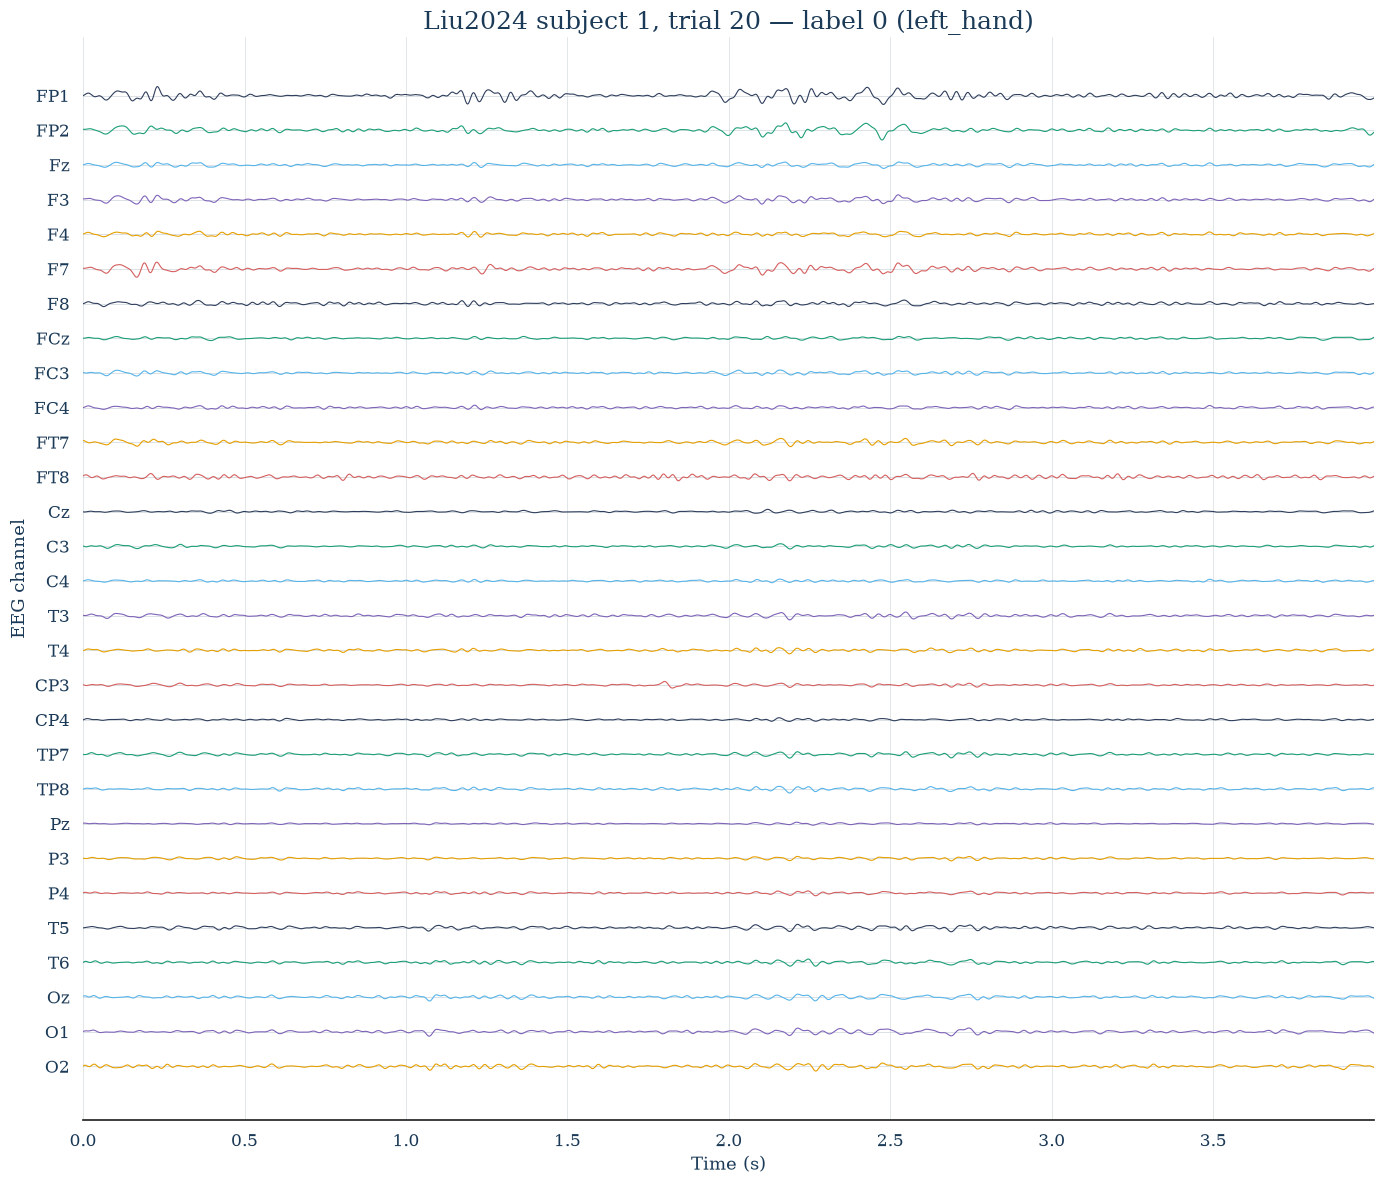

Dataset index: 20
Subject: 1
Trial: 20
Numeric target: 0
Label: left_hand
Window shape: (29, 2000)


In [25]:
import matplotlib.pyplot as plt

TRIAL_WITHIN_SUBJECT = 20
N_CHANNELS_TO_PLOT = 29

matches = subject_rows[
    saved_dataset.trial_indices[subject_rows] == TRIAL_WITHIN_SUBJECT
]
if len(matches) != 1:
    raise ValueError(
        f'Expected one match for subject {SUBJECT_ID}, trial {TRIAL_WITHIN_SUBJECT}; '
        f'found {len(matches)}'
    )

dataset_index = int(matches[0])
x, target, sample_info = saved_dataset[dataset_index]
signal = x.numpy()
sfreq = float(saved_dataset.metadata['sampling_frequency_hz'])
times = np.arange(signal.shape[1]) / sfreq
channel_names = saved_dataset.metadata['channel_names'][:N_CHANNELS_TO_PLOT]
display_signal = signal[:N_CHANNELS_TO_PLOT]
spacing = max(float(np.nanpercentile(np.abs(display_signal), 99)) * 2.5, 1.0)
offsets = np.arange(N_CHANNELS_TO_PLOT)[::-1] * spacing

fig, ax = plt.subplots(figsize=(14, 12))
for channel_index, (channel_name, offset) in enumerate(zip(channel_names, offsets)):
    ax.plot(times, display_signal[channel_index] + offset, linewidth=0.8)
ax.set_yticks(offsets, channel_names)
ax.set_xlabel('Time (s)')
ax.set_ylabel('EEG channel')
ax.set_title(
    f"Liu2024 subject {sample_info['subject']}, trial {sample_info['trial']} — "
    f"label {target} ({label_names[target]})"
)
ax.set_xlim(times[0], times[-1])
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

print('Dataset index:', dataset_index)
print('Subject:', sample_info['subject'])
print('Trial:', sample_info['trial'])
print('Numeric target:', target)
print('Label:', label_names[target])
print('Window shape:', tuple(x.shape))

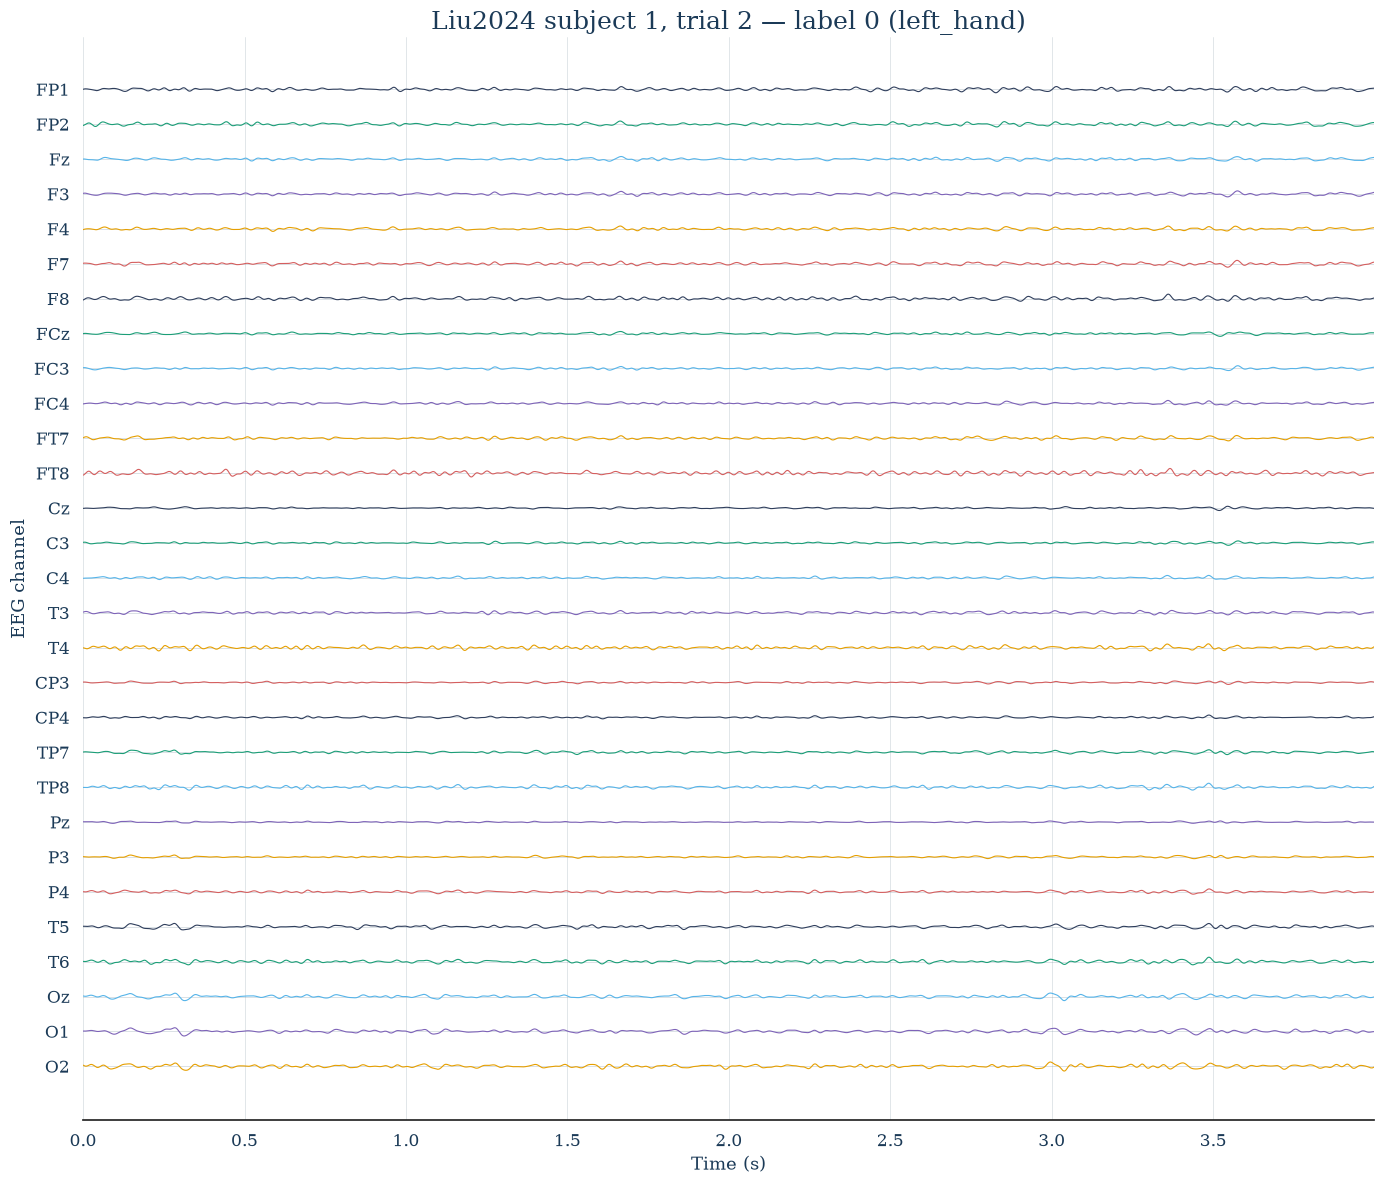

Dataset index: 2
Subject: 1
Trial: 2
Numeric target: 0
Label: left_hand
Window shape: (29, 2000)


In [26]:
import matplotlib.pyplot as plt

TRIAL_WITHIN_SUBJECT = 2
N_CHANNELS_TO_PLOT = 29

matches = subject_rows[
    saved_dataset.trial_indices[subject_rows] == TRIAL_WITHIN_SUBJECT
]
if len(matches) != 1:
    raise ValueError(
        f'Expected one match for subject {SUBJECT_ID}, trial {TRIAL_WITHIN_SUBJECT}; '
        f'found {len(matches)}'
    )

dataset_index = int(matches[0])
x, target, sample_info = saved_dataset[dataset_index]
signal = x.numpy()
sfreq = float(saved_dataset.metadata['sampling_frequency_hz'])
times = np.arange(signal.shape[1]) / sfreq
channel_names = saved_dataset.metadata['channel_names'][:N_CHANNELS_TO_PLOT]
display_signal = signal[:N_CHANNELS_TO_PLOT]
spacing = max(float(np.nanpercentile(np.abs(display_signal), 99)) * 2.5, 1.0)
offsets = np.arange(N_CHANNELS_TO_PLOT)[::-1] * spacing

fig, ax = plt.subplots(figsize=(14, 12))
for channel_index, (channel_name, offset) in enumerate(zip(channel_names, offsets)):
    ax.plot(times, display_signal[channel_index] + offset, linewidth=0.8)
ax.set_yticks(offsets, channel_names)
ax.set_xlabel('Time (s)')
ax.set_ylabel('EEG channel')
ax.set_title(
    f"Liu2024 subject {sample_info['subject']}, trial {sample_info['trial']} — "
    f"label {target} ({label_names[target]})"
)
ax.set_xlim(times[0], times[-1])
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

print('Dataset index:', dataset_index)
print('Subject:', sample_info['subject'])
print('Trial:', sample_info['trial'])
print('Numeric target:', target)
print('Label:', label_names[target])
print('Window shape:', tuple(x.shape))